/Users/filipporonzino/anaconda3/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/filipporonzino/Desktop/thesis


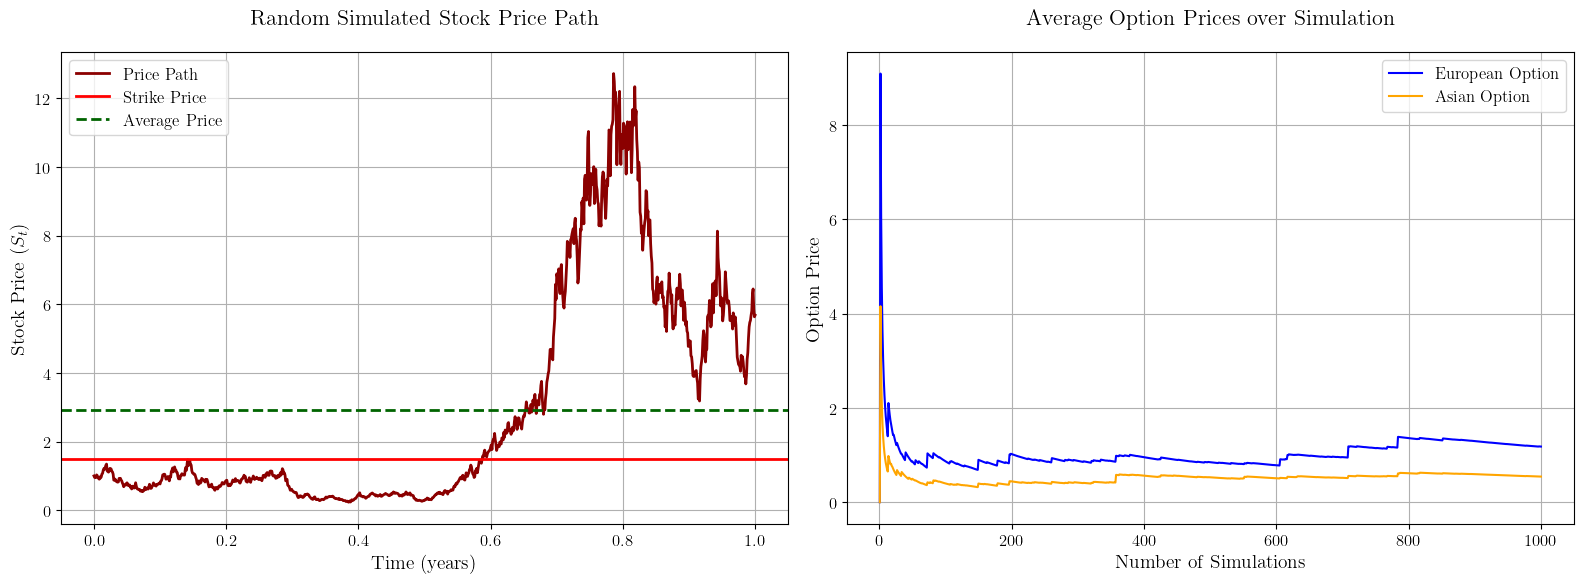

Final plot saved to plots/random_simulation_side_by_side.png

Final Results:
Average European Option Price: 1.1798
Average Asian Option Price: 0.5428
Difference (European - Asian): 0.6370


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import os
%cd ..
from src.monte_carlo.asianoption import AsianOption
from src.monte_carlo.vanillaoption import VanillaOption
from src.monte_carlo.mcpricer import MCPricer

def simulate_option_prices_random(n_sim=1000, N=1000, sigma=2, r=0.5, K=1.5, save_dir="plots") -> tuple:
    """
    Simulate and compare Asian and European option prices, displaying a random path and average prices side-by-side.
    
    :param n_sim: number of simulations
    :param N: number of time steps
    :param sigma: volatility
    :param r: risk-free rate
    :param K: strike price
    :param save_dir: directory to save the final plot
    :return: average European and Asian option prices
    """
    rc("text", usetex=True)
    rc("font", family="serif", size=12)
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    pricer = MCPricer(n_sims=n_sim, n_steps=N)
    
    asian_option = AsianOption(S0=1, K=K, T=1, r=r, sigma=sigma, n_steps=N, option_type='arithmetic')
    european_option = VanillaOption(S0=1, K=K, T=1, r=r, sigma=sigma, option_type='european')
    
    stock_paths = pricer.generate_paths(european_option)
    
    european_payoffs = european_option.payoff(stock_paths)
    asian_payoffs = asian_option.payoff(stock_paths)
    
    random_index = np.random.randint(0, n_sim)
    random_path = stock_paths[random_index]
    random_avg_price = np.mean(random_path)
    
    avg_european = np.mean(european_payoffs)
    avg_asian = np.mean(asian_payoffs)
    
    t = np.linspace(0, 1, N + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    color = 'darkred' if random_path[-1] > random_avg_price else 'darkgreen'
    ax1.plot(t, np.insert(random_path, 0, 1), color=color, linewidth=2, label='Price Path')
    ax1.axhline(y=K, color='red', linestyle='-', linewidth=2, label='Strike Price')
    ax1.axhline(y=random_avg_price, color='darkgreen', linestyle='--', linewidth=2, label='Average Price')
    ax1.set_title('Random Simulated Stock Price Path', fontsize=16, pad=20)
    ax1.set_xlabel('Time (years)', fontsize=14)
    ax1.set_ylabel('Stock Price ($S_t$)', fontsize=14)
    ax1.grid(True)
    ax1.legend(loc='upper left')
    
    ax2.plot(range(1, n_sim + 1), [np.mean(european_payoffs[:i]) for i in range(1, n_sim + 1)],
             label='European Option', color='blue')
    ax2.plot(range(1, n_sim + 1), [np.mean(asian_payoffs[:i]) for i in range(1, n_sim + 1)],
             label='Asian Option', color='orange')
    ax2.set_title('Average Option Prices over Simulation', fontsize=16, pad=20)
    ax2.set_xlabel('Number of Simulations', fontsize=14)
    ax2.set_ylabel('Option Price', fontsize=14)
    ax2.legend(loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/random_simulation_side_by_side.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Final plot saved to {save_dir}/random_simulation_side_by_side.png")
    return avg_european, avg_asian

np.random.seed(42)
european_price, asian_price = simulate_option_prices_random()
print(f"\nFinal Results:")
print(f"Average European Option Price: {european_price:.4f}")
print(f"Average Asian Option Price: {asian_price:.4f}")
print(f"Difference (European - Asian): {european_price - asian_price:.4f}")